In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.special import expit as sigmoid
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, LinearRegression

In [2]:
from utils import DataHandler
from ESN import ESNetwork, ClassicalRC
from reservoirs import CPRC, GBPermanents

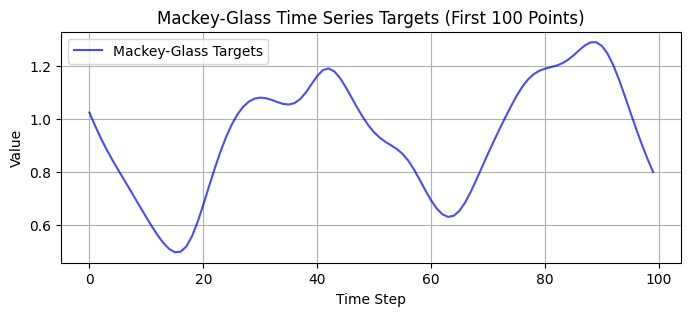

In [3]:
window_size = 10
n_samples = 5000
# X, Y = DataHandler().load_dataset('narma', n_samples = 1000, window_size=4, plot=True)
X, Y = DataHandler().load_dataset('mackey_glass', n_samples = n_samples, tau = 17, window_size=window_size,prediction_horizon=20, plot=True)

In [4]:
tr = 0.75
train_size = int(n_samples*tr)  # Training set size
# Split into training and testing sets
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = Y[:train_size], Y[train_size:]

In [5]:
noise_levels= np.linspace(0.0001, 0.1, 20)
noise_levels

array([0.0001    , 0.00535789, 0.01061579, 0.01587368, 0.02113158,
       0.02638947, 0.03164737, 0.03690526, 0.04216316, 0.04742105,
       0.05267895, 0.05793684, 0.06319474, 0.06845263, 0.07371053,
       0.07896842, 0.08422632, 0.08948421, 0.09474211, 0.1       ])

In [6]:
# np.save("cp_mse.npy", np.array(cpk_mse))
# np.save("cp_preds.npy", np.array(cpk_preds))
# np.save("noise.npy", np.array(noise_levels))

In [7]:
from joblib import Parallel, delayed
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

def run_noise_trial(noise_level, X_train, y_train, X_test, y_test, dim):
    cprc = CPRC(dim=dim, execution_mode='noise', kernel=True, noise_level=noise_level)
    esn = ESNetwork(
        reservoir=cprc,
        dim=dim,
        regularization=1e-6,
        alpha=0.79,
        show_progress=True,
        approach='feedback',
        model_type='ridge',
        limit=0.9,
        cpk=True
    )
    esn.fit(X_train, y_train)
    predictions = esn.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    print(f"MSE: {mse}")
    return {"noise_level": noise_level, "mse": mse, "predictions": predictions}


In [8]:
dim = X_train.shape[1]

results = Parallel(n_jobs=-1)(
    delayed(run_noise_trial)(n, X_train, y_train, X_test, y_test, dim)
    for n in tqdm(noise_levels, desc="Running QRC under noise")
)

Prediction Progress:  93%|█████████▎| 1134/1221 [02:37<00:13,  6.53 sample/s]

MSE: 0.00789141213169839


Training Progress:   0%|          | 1/3750 [00:00<08:07,  7.70 sample/s]le/s]

MSE: 0.0313044021746578


Training Progress:   0%|          | 1/3750 [00:00<09:19,  6.70 sample/s]le/s]

...

MSE: 0.05719873660944412


Training Progress:  97%|█████████▋| 3642/3750 [05:20<00:09, 11.31 sample/s]

MSE: 0.057321819011699755


Prediction Progress: 100%|██████████| 1221/1221 [01:43<00:00, 11.77 sample/s]


KeyError: 'rmse'

In [9]:
# Extract values
cpk_mse = [r["mse"] for r in results]
cpk_preds = [r["predictions"] for r in results]

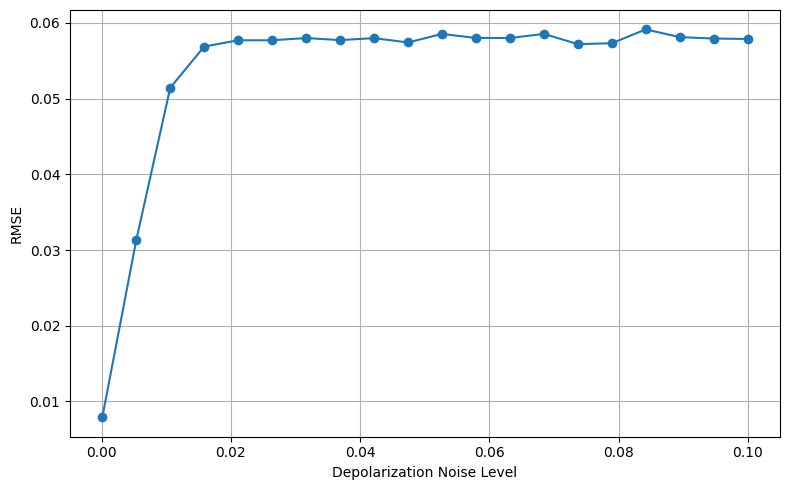

MSE: 0.05915062073376102
MSE: 0.05794426362295603
MSE: 0.05812742569183453
MSE: 0.05788299211924921


In [12]:
plt.figure(figsize=(8, 5))
plt.plot(noise_levels, cpk_mse, marker='o')
plt.xlabel("Depolarization Noise Level")
plt.ylabel("RMSE")
# plt.title("QRC Sensitivity to Depolarizing Noise")
plt.grid(True)
plt.tight_layout()
plt.savefig("Paper_results/figures/qrc_noise_sensitivity.pdf")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(noise_levels, cpk_mse, marker='o', linestyle='-', color='b', label='MSE')
plt.xlabel("Depol. Noise Level (σ)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Quantum ESN Predictions with CPKernel Vs Depol. Noise")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
predictions = cpk_preds[99]
# print(predictions)